<a href="https://colab.research.google.com/github/o0Junny0o/DashboardNetflix/blob/main/Classificacao_de_textos_do_twitter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import re
import string
import spacy
import pandas as pd
import random

In [ ]:
!python -m spacy download pt_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 69.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
!head Test.csv

id;tweet_text;tweet_date;sentiment;query_used
1029536486021099522;@Gazo1a Nossa! Muito obrigada :);Wed Aug 15 01:13:20 +0000 2018;1;:)
1029536496368406528;@BerzGamer vai pa puta que te pariu :);Wed Aug 15 01:13:23 +0000 2018;1;:)
1029536531655131137;"QUER MAIS DESCONTOS? (14/08) ⭐⭐⭐⭐⭐ 🌐 Confira no link ➔ https://t.co/jhh0Ttlpq3 | » Compartilhe! « Não encontrou a oferta ou cupom que procurava? Não se preocupe ;) criamos uma pagina com mais ofertas e cupons atualizada diariamente :) https://t.co/IgeeD0WmPf";Wed Aug 15 01:13:31 +0000 2018;1;:)
1029536560117678081;EU VOU PEGAR VCS, ME AJUDEM GALERA, PELO AMOR DE BUTERA. :) #MMVAs #iHeartRadioMMVAs #FFSingleNoTears https://t.co/ghZMLqRFiV;Wed Aug 15 01:13:38 +0000 2018;1;:)
1029536605852377088;Estávamos em casa do Zé e eu estava a morrer de sono, chego a casa e fico sem sono :))));Wed Aug 15 01:13:49 +0000 2018;1;:)
1029536620368863234;Precisa :) https://t.co/DcLGDHbjT0;Wed Aug 15 01:13:52 +0000 2018;1;:)
1029536626656129024;@Jeniabreu07 ma

In [ ]:
base_treinamento = pd.read_csv('Test.csv', sep=';')

# Display the first few rows to confirm it's loaded correctly
display(base_treinamento.head())

,id,tweet_text,tweet_date,sentiment,query_used
0,1029536486021099522,@Gazo1a Nossa! Muito obrigada :),Wed Aug 15 01:13:20 +0000 2018,1,:)
1,1029536496368406528,@BerzGamer vai pa puta que te pariu :),Wed Aug 15 01:13:23 +0000 2018,1,:)
2,1029536531655131137,QUER MAIS DESCONTOS? (14/08) ⭐⭐⭐⭐⭐ 🌐 Confira n...,Wed Aug 15 01:13:31 +0000 2018,1,:)
3,1029536560117678081,"EU VOU PEGAR VCS, ME AJUDEM GALERA, PELO AMOR ...",Wed Aug 15 01:13:38 +0000 2018,1,:)
4,1029536605852377088,Estávamos em casa do Zé e eu estava a morrer d...,Wed Aug 15 01:13:49 +0000 2018,1,:)


In [ ]:
base_treinamento.drop(['id', 'tweet_date', 'query_used'], axis = 1, inplace=True)

In [ ]:
# Load the Portuguese language model
pln = spacy.load('pt_core_news_sm')

# Get the stop words for Portuguese
stop_words = spacy.lang.pt.stop_words.STOP_WORDS

def preprocessamento(texto):
  # Letras minúsculas
  texto = texto.lower()

  # Nome do usuário
  texto = re.sub(r"@[A-Za-z0-9$-_@.&+]+", ' ', texto)

  # URLs
  texto = re.sub(r"https?://[A-Za-z0-9./]+", ' ', texto)

  # Espaços em branco
  texto = re.sub(r" +", ' ', texto)

  # Emoticons
  lista_emocoes = {':)': 'emocaopositiva',
                   ':d': 'emocaopositiva',
                   ':(': 'emocaonegativa'}
  for emocao in lista_emocoes:
    texto = texto.replace(emocao, lista_emocoes[emocao])

  # Lematização
  documento = pln(texto)

  lista = []
  for token in documento:
    lista.append(token.lemma_)

  # Stop words e pontuações
  lista = [palavra for palavra in lista if palavra not in stop_words and palavra not in string.punctuation]
  lista = ' '.join([str(elemento) for elemento in lista if not elemento.isdigit()])

  return lista

In [ ]:
base_treinamento['tweet_text'] = base_treinamento['tweet_text'].apply(preprocessamento)

In [ ]:
base_dados_treinamento_final = []
for texto, emocao in zip(base_treinamento['tweet_text'], base_treinamento['sentiment']):
  if emocao == 1:
    dic = ({'POSITIVO': True, 'NEGATIVO': False})
  elif emocao == 0:
    dic = ({'POSITIVO': False, 'NEGATIVO': True})

  base_dados_treinamento_final.append([texto, dic.copy()])


In [ ]:
len(base_dados_treinamento_final)

5000

In [ ]:
modelo = spacy.blank('pt')
modelo.add_pipe("textcat")
modelo.get_pipe("textcat").add_label("POSITIVO")
modelo.get_pipe("textcat").add_label("NEGATIVO")
historico = []

In [ ]:
from spacy.training import Example

modelo.begin_training()
for epoca in range(20):
  random.shuffle(base_dados_treinamento_final)
  losses = {}
  # Create Example objects for training
  examples = [Example.from_dict(modelo.make_doc(text), {"cats": entities}) for text, entities in base_dados_treinamento_final]
  for batch in spacy.util.minibatch(examples, 512):
    modelo.update(batch, losses=losses)
  historico.append(losses)
  if epoca % 5 == 0:
    print(losses)

{'textcat': 1.377065123990178}
{'textcat': 3.515850632873109e-09}
{'textcat': 1.6488480615313005e-10}
{'textcat': 6.835094133478964e-11}


In [ ]:
historico_loss = []
for i in historico:
  historico_loss.append(i.get('textcat'))

In [ ]:
import numpy as np

historico_loss = np.array(historico_loss)
historico_loss

array([1.37706512e+00, 6.92064697e-02, 5.49461057e-03, 4.45246126e-05,
       1.88616467e-07, 3.51585063e-09, 1.19799459e-09, 5.97026674e-10,
       3.03260704e-10, 2.20903008e-10, 1.64884806e-10, 1.32827071e-10,
       1.04766895e-10, 8.99285341e-11, 7.40453132e-11, 6.83509413e-11,
       5.48257279e-11, 4.73393576e-11, 4.06034882e-11, 4.37577914e-11])

Text(0, 0.5, 'Erro')

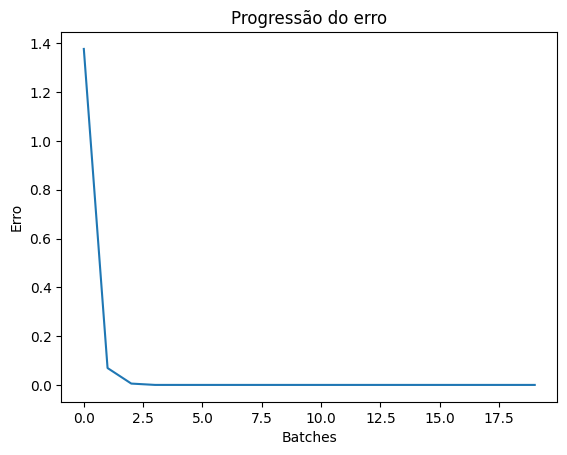

In [ ]:
import matplotlib.pyplot as plt
plt.plot(historico_loss)
plt.title('Progressão do erro')
plt.xlabel('Batches')
plt.ylabel('Erro')

In [ ]:
modelo.to_disk("modelo")

In [ ]:
!zip -r /content/modelo.zip /content/modelo

updating: content/modelo/ (stored 0%)
updating: content/modelo/vocab/ (stored 0%)
updating: content/modelo/vocab/vectors (deflated 45%)
updating: content/modelo/vocab/lookups.bin (stored 0%)
updating: content/modelo/vocab/strings.json (deflated 74%)
updating: content/modelo/vocab/vectors.cfg (stored 0%)
updating: content/modelo/vocab/key2row (stored 0%)
updating: content/modelo/textcat/ (stored 0%)
updating: content/modelo/textcat/model (deflated 54%)
updating: content/modelo/textcat/cfg (deflated 19%)
updating: content/modelo/tokenizer (deflated 84%)
updating: content/modelo/meta.json (deflated 49%)
updating: content/modelo/config.cfg (deflated 61%)


In [ ]:
modelo_carregado = spacy.load('/content/modelo')
modelo_carregado

Frases Positivas

In [ ]:
texto = "Hoje o meu time jogou o fino do fino"

texto = preprocessamento(texto)
print(texto)

previsao = modelo_carregado(texto)
previsao

print(previsao.cats)

actual_sentiment = 1

doc = modelo_carregado(texto)

predicted_label = 1 if doc.cats['POSITIVO'] > doc.cats['NEGATIVO'] else 0

if predicted_label == actual_sentiment:
  print("A previsão está correta!")
else:
  print("A previsão está incorreta.")

actual_sentiments = []
predicted_sentiments = []
actual_sentiments.append(actual_sentiment)
predicted_sentiments.append(predicted_label)

hoje time jogar fino de o fino
{'POSITIVO': 0.9991425275802612, 'NEGATIVO': 0.000857464678119868}
A previsão está correta!


In [ ]:
texto = "Relaxa e curte a vibe, que hoje vai dar bom!"

texto = preprocessamento(texto)
print(texto)

previsao = modelo_carregado(texto)
previsao

print(previsao.cats)

actual_sentiment = 1

doc = modelo_carregado(texto)

predicted_label = 1 if doc.cats['POSITIVO'] > doc.cats['NEGATIVO'] else 0

if predicted_label == actual_sentiment:
  print("A previsão está correta!")
else:
  print("A previsão está incorreta.")

actual_sentiments = []
predicted_sentiments = []
actual_sentiments.append(actual_sentiment)
predicted_sentiments.append(predicted_label)

relaxa curte vibe hoje
{'POSITIVO': 0.998392641544342, 'NEGATIVO': 0.0016073074657469988}
A previsão está correta!


In [ ]:
texto = "A vida tá on, é só ir pra cima."

texto = preprocessamento(texto)
print(texto)

previsao = modelo_carregado(texto)
previsao

print(previsao.cats)

actual_sentiment = 1

doc = modelo_carregado(texto)

predicted_label = 1 if doc.cats['POSITIVO'] > doc.cats['NEGATIVO'] else 0

if predicted_label == actual_sentiment:
  print("A previsão está correta!")
else:
  print("A previsão está incorreta.")

actual_sentiments = []
predicted_sentiments = []
actual_sentiments.append(actual_sentiment)
predicted_sentiments.append(predicted_label)

vida tá on pra
{'POSITIVO': 0.9975013136863708, 'NEGATIVO': 0.002498660935088992}
A previsão está correta!


In [ ]:
texto = "Bora lá! Se não deu certo, a gente tenta de novo. Sem estresse!"

texto = preprocessamento(texto)
print(texto)

previsao = modelo_carregado(texto)
previsao

print(previsao.cats)

actual_sentiment = 1

doc = modelo_carregado(texto)

predicted_label = 1 if doc.cats['POSITIVO'] > doc.cats['NEGATIVO'] else 0

if predicted_label == actual_sentiment:
  print("A previsão está correta!")
else:
  print("A previsão está incorreta.")

actual_sentiments = []
predicted_sentiments = []
actual_sentiments.append(actual_sentiment)
predicted_sentiments.append(predicted_label)

bor certo gente estresse
{'POSITIVO': 0.16596321761608124, 'NEGATIVO': 0.8340368270874023}
A previsão está incorreta.


In [ ]:
texto = "Fica de boa. O universo tá conspirando a seu favor."

texto = preprocessamento(texto)
print(texto)

previsao = modelo_carregado(texto)
previsao

print(previsao.cats)

actual_sentiment = 1

doc = modelo_carregado(texto)

predicted_label = 1 if doc.cats['POSITIVO'] > doc.cats['NEGATIVO'] else 0

if predicted_label == actual_sentiment:
  print("A previsão está correta!")
else:
  print("A previsão está incorreta.")

actual_sentiments = []
predicted_sentiments = []
actual_sentiments.append(actual_sentiment)
predicted_sentiments.append(predicted_label)

ficar universo tá conspirar
{'POSITIVO': 0.9576064944267273, 'NEGATIVO': 0.04239346832036972}
A previsão está correta!


In [ ]:
texto = "Tudo nosso e nada deles"

texto = preprocessamento(texto)
print(texto)

previsao = modelo_carregado(texto)
previsao

print(previsao.cats)

actual_sentiment = 1

doc = modelo_carregado(texto)

predicted_label = 1 if doc.cats['POSITIVO'] > doc.cats['NEGATIVO'] else 0

if predicted_label == actual_sentiment:
  print("A previsão está correta!")
else:
  print("A previsão está incorreta.")

actual_sentiments = []
predicted_sentiments = []
actual_sentiments.append(actual_sentiment)
predicted_sentiments.append(predicted_label)

de eles
{'POSITIVO': 0.9639606475830078, 'NEGATIVO': 0.03603936731815338}
A previsão está correta!


In [ ]:
texto = "Tá tudo show! Foco no que te faz feliz e simbora!"

texto = preprocessamento(texto)
print(texto)

previsao = modelo_carregado(texto)
previsao

print(previsao.cats)

actual_sentiment = 1

doc = modelo_carregado(texto)

predicted_label = 1 if doc.cats['POSITIVO'] > doc.cats['NEGATIVO'] else 0

if predicted_label == actual_sentiment:
  print("A previsão está correta!")
else:
  print("A previsão está incorreta.")

actual_sentiments = []
predicted_sentiments = []
actual_sentiments.append(actual_sentiment)
predicted_sentiments.append(predicted_label)

tá show foco em o feliz simbor
{'POSITIVO': 0.9882735013961792, 'NEGATIVO': 0.011726493015885353}
A previsão está correta!


In [ ]:
texto = "Não esquenta a cabeça, não. No final, tudo se ajeita."

texto = preprocessamento(texto)
print(texto)

previsao = modelo_carregado(texto)
previsao

print(previsao.cats)

actual_sentiment = 1

doc = modelo_carregado(texto)

predicted_label = 1 if doc.cats['POSITIVO'] > doc.cats['NEGATIVO'] else 0

if predicted_label == actual_sentiment:
  print("A previsão está correta!")
else:
  print("A previsão está incorreta.")

actual_sentiments = []
predicted_sentiments = []
actual_sentiments.append(actual_sentiment)
predicted_sentiments.append(predicted_label)

esquentar cabeça em o ajeitar
{'POSITIVO': 0.9982122182846069, 'NEGATIVO': 0.0017878517974168062}
A previsão está correta!


In [ ]:
texto = "Meu parceiro, a vida é curta demais pra treta. Só gratidão!"

texto = preprocessamento(texto)
print(texto)

previsao = modelo_carregado(texto)
previsao

print(previsao.cats)

actual_sentiment = 1

doc = modelo_carregado(texto)

predicted_label = 1 if doc.cats['POSITIVO'] > doc.cats['NEGATIVO'] else 0

if predicted_label == actual_sentiment:
  print("A previsão está correta!")
else:
  print("A previsão está incorreta.")

actual_sentiments = []
predicted_sentiments = []
actual_sentiments.append(actual_sentiment)
predicted_sentiments.append(predicted_label)

parceiro vida curto pra treta gratidão
{'POSITIVO': 0.9950966238975525, 'NEGATIVO': 0.004903367254883051}
A previsão está correta!


In [ ]:
texto = "Tô animadão, hoje o dia tá virando top!"

texto = preprocessamento(texto)
print(texto)

previsao = modelo_carregado(texto)
previsao

print(previsao.cats)

actual_sentiment = 1

doc = modelo_carregado(texto)

predicted_label = 1 if doc.cats['POSITIVO'] > doc.cats['NEGATIVO'] else 0

if predicted_label == actual_sentiment:
  print("A previsão está correta!")
else:
  print("A previsão está incorreta.")

actual_sentiments = []
predicted_sentiments = []
actual_sentiments.append(actual_sentiment)
predicted_sentiments.append(predicted_label)

tô animadão hoje dia tá virar top
{'POSITIVO': 0.994681179523468, 'NEGATIVO': 0.0053188614547252655}
A previsão está correta!


Frases negativas


In [ ]:
texto = "De jeito nenhum! Tô fora dessa parada."

texto = preprocessamento(texto)
print(texto)

previsao = modelo_carregado(texto)
previsao

print(previsao.cats)

actual_sentiment = 0

doc = modelo_carregado(texto)

predicted_label = 1 if doc.cats['POSITIVO'] > doc.cats['NEGATIVO'] else 0

if predicted_label == actual_sentiment:
  print("A previsão está correta!")
else:
  print("A previsão está incorreta.")

actual_sentiments = []
predicted_sentiments = []
actual_sentiments.append(actual_sentiment)
predicted_sentiments.append(predicted_label)

jeito nenhum tô de esse parada
{'POSITIVO': 0.9958688020706177, 'NEGATIVO': 0.004131189081817865}
A previsão está incorreta.


In [ ]:
texto = "Esquece! Não tô com cabeça pra isso hoje, sério mesmo."

texto = preprocessamento(texto)
print(texto)

previsao = modelo_carregado(texto)
previsao

print(previsao.cats)

actual_sentiment = 0

doc = modelo_carregado(texto)

predicted_label = 1 if doc.cats['POSITIVO'] > doc.cats['NEGATIVO'] else 0

if predicted_label == actual_sentiment:
  print("A previsão está correta!")
else:
  print("A previsão está incorreta.")

actual_sentiments = []
predicted_sentiments = []
actual_sentiments.append(actual_sentiment)
predicted_sentiments.append(predicted_label)

esquecer tô cabeça pra hoje sério
{'POSITIVO': 0.9324138760566711, 'NEGATIVO': 0.06758613884449005}
A previsão está incorreta.


In [ ]:
texto = "Nossa, que perrengue! Não consegui resolver nada."

texto = preprocessamento(texto)
print(texto)

previsao = modelo_carregado(texto)
previsao

print(previsao.cats)

actual_sentiment = 0

doc = modelo_carregado(texto)

predicted_label = 1 if doc.cats['POSITIVO'] > doc.cats['NEGATIVO'] else 0

if predicted_label == actual_sentiment:
  print("A previsão está correta!")
else:
  print("A previsão está incorreta.")

actual_sentiments = []
predicted_sentiments = []
actual_sentiments.append(actual_sentiment)
predicted_sentiments.append(predicted_label)

perrengar conseguir resolver
{'POSITIVO': 0.9995423555374146, 'NEGATIVO': 0.0004576628271024674}
A previsão está incorreta.


In [ ]:
texto = "Nem a pau, Truta! Não vou topar fazer essa loucura."

texto = preprocessamento(texto)
print(texto)

previsao = modelo_carregado(texto)
previsao

print(previsao.cats)

actual_sentiment = 0

doc = modelo_carregado(texto)

predicted_label = 1 if doc.cats['POSITIVO'] > doc.cats['NEGATIVO'] else 0

if predicted_label == actual_sentiment:
  print("A previsão está correta!")
else:
  print("A previsão está incorreta.")

actual_sentiments = []
predicted_sentiments = []
actual_sentiments.append(actual_sentiment)
predicted_sentiments.append(predicted_label)

pau truta topar loucura
{'POSITIVO': 0.9983519315719604, 'NEGATIVO': 0.001648118020966649}
A previsão está incorreta.


In [ ]:
texto = "Ih, deu ruim. Não vai sobrar grana pra pagar as contas."

texto = preprocessamento(texto)
print(texto)

previsao = modelo_carregado(texto)
previsao

print(previsao.cats)

actual_sentiment = 0

doc = modelo_carregado(texto)

predicted_label = 1 if doc.cats['POSITIVO'] > doc.cats['NEGATIVO'] else 0

if predicted_label == actual_sentiment:
  print("A previsão está correta!")
else:
  print("A previsão está incorreta.")

actual_sentiments = []
predicted_sentiments = []
actual_sentiments.append(actual_sentiment)
predicted_sentiments.append(predicted_label)

ih ruim sobrar grano pra pagar conta
{'POSITIVO': 0.9958500862121582, 'NEGATIVO': 0.004149887710809708}
A previsão está incorreta.


In [ ]:
texto = "Que bad! Não tô no clima pra sair hoje, prefiro ficar de boa."

texto = preprocessamento(texto)
print(texto)

previsao = modelo_carregado(texto)
previsao

print(previsao.cats)

actual_sentiment = 0

doc = modelo_carregado(texto)

predicted_label = 1 if doc.cats['POSITIVO'] > doc.cats['NEGATIVO'] else 0

if predicted_label == actual_sentiment:
  print("A previsão está correta!")
else:
  print("A previsão está incorreta.")

actual_sentiments = []
predicted_sentiments = []
actual_sentiments.append(actual_sentiment)
predicted_sentiments.append(predicted_label)

bad tô em o clima pra sair hoje prefiro ficar
{'POSITIVO': 0.9829487800598145, 'NEGATIVO': 0.01705116592347622}
A previsão está incorreta.


In [ ]:
texto = "Esse é ruim, hein? Não curti o game de jeito nenhum."

texto = preprocessamento(texto)
print(texto)

previsao = modelo_carregado(texto)
previsao

print(previsao.cats)

actual_sentiment = 0

doc = modelo_carregado(texto)

predicted_label = 1 if doc.cats['POSITIVO'] > doc.cats['NEGATIVO'] else 0

if predicted_label == actual_sentiment:
  print("A previsão está correta!")
else:
  print("A previsão está incorreta.")

actual_sentiments = []
predicted_sentiments = []
actual_sentiments.append(actual_sentiment)

ruim hein curtir game jeito nenhum
{'POSITIVO': 0.9936419129371643, 'NEGATIVO': 0.006358094047755003}
A previsão está incorreta.


In [ ]:
texto = "Mó vacilo. Não curti o que rolou."

texto = preprocessamento(texto)
print(texto)

previsao = modelo_carregado(texto)
previsao

print(previsao.cats)

actual_sentiment = 0

doc = modelo_carregado(texto)

predicted_label = 1 if doc.cats['POSITIVO'] > doc.cats['NEGATIVO'] else 0

if predicted_label == actual_sentiment:
  print("A previsão está correta!")
else:
  print("A previsão está incorreta.")

actual_sentiments = []
predicted_sentiments = []
actual_sentiments.append(actual_sentiment)

mó vacilo curtir rolar
{'POSITIVO': 0.9974435567855835, 'NEGATIVO': 0.002556389896199107}
A previsão está incorreta.


In [ ]:
texto = "Não tenho energia nem pra levantar da cama."

texto = preprocessamento(texto)
print(texto)

previsao = modelo_carregado(texto)
previsao

print(previsao.cats)

actual_sentiment = 0

doc = modelo_carregado(texto)

predicted_label = 1 if doc.cats['POSITIVO'] > doc.cats['NEGATIVO'] else 0

if predicted_label == actual_sentiment:
  print("A previsão está correta!")
else:
  print("A previsão está incorreta.")

actual_sentiments = []
predicted_sentiments = []
actual_sentiments.append(actual_sentiment)

energia pra levantar de o cama
{'POSITIVO': 0.7551380395889282, 'NEGATIVO': 0.2448619306087494}
A previsão está incorreta.


In [ ]:
texto = "Você não ta me mostrando isso com a internet que eu pago não né?"

texto = preprocessamento(texto)
print(texto)

previsao = modelo_carregado(texto)
previsao

print(previsao.cats)

actual_sentiment = 0

doc = modelo_carregado(texto)

predicted_label = 1 if doc.cats['POSITIVO'] > doc.cats['NEGATIVO'] else 0

if predicted_label == actual_sentiment:
  print("A previsão está correta!")
else:
  print("A previsão está incorreta.")

actual_sentiments = []
predicted_sentiments = []
actual_sentiments.append(actual_sentiment)

ta mostrar Internet pagar né
{'POSITIVO': 0.0003766281879507005, 'NEGATIVO': 0.9996232986450195}
A previsão está correta!


A acurácia do modelo é: 0.5


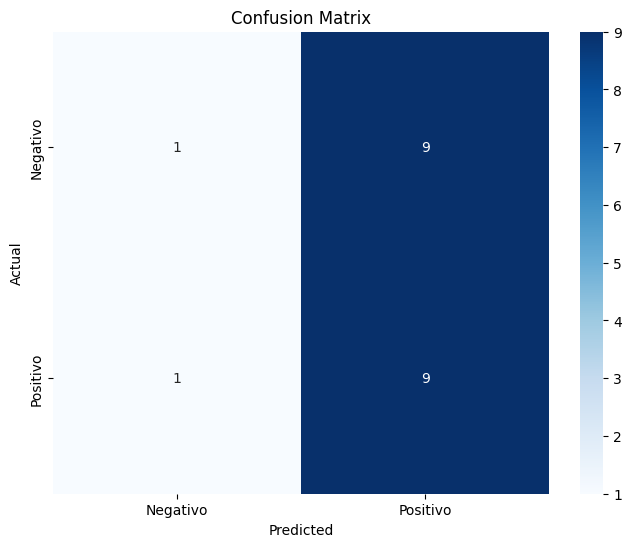

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix

actual_sentiments = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
predicted_sentiments = []

texts = [
    "Hoje o meu time jogou o fino do fino",
    "Relaxa e curte a vibe, que hoje vai dar bom!",
    "A vida tá on, é só ir pra cima.",
    "Bora lá! Se não deu certo, a gente tenta de novo. Sem estresse!",
    "Fica de boa. O universo tá conspirando a seu favor.",
    "Tudo nosso e nada deles",
    "Tá tudo show! Foco no que te faz feliz e simbora!",
    "Não esquenta a cabeça, não. No final, tudo se ajeita.",
    "Meu parceiro, a vida é curta demais pra treta. Só gratidão!",
    "Tô animadão, hoje o dia tá virando top!",
    "De jeito nenhum! Tô fora dessa parada.",
    "Esquece! Não tô com cabeça pra isso hoje, sério mesmo.",
    "Nossa, que perrengue! Não consegui resolver nada.",
    "Nem a pau, Truta! Não vou topar fazer essa loucura.",
    "Ih, deu ruim. Não vai sobrar grana pra pagar as contas.",
    "Que bad! Não tô no clima pra sair hoje, prefiro ficar de boa.",
    "Esse é ruim, hein? Não curti o game de jeito nenhum.",
    "Mó vacilo. Não curti o que rolou.",
    "Não tenho energia nem pra levantar da cama.",
    "Você não ta me mostrando isso com a internet que eu pago não né?"
]

for texto in texts:
    texto_preprocessado = preprocessamento(texto)
    doc = modelo_carregado(texto_preprocessado)
    predicted_label = 1 if doc.cats['POSITIVO'] > doc.cats['NEGATIVO'] else 0
    predicted_sentiments.append(predicted_label)

accuracy = accuracy_score(actual_sentiments, predicted_sentiments)
print(f"A acurácia do modelo é: {accuracy}")

conf_matrix = confusion_matrix(actual_sentiments, predicted_sentiments)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()